


Ex05에서 사용한 단일 LSTM 구조와 학습 조건을 고정하고, 입력을 만드는 tokenizer만 바꾼다.  

비교 조건은 다음과 같다.  

| experiment | tokenizer | model type | target vocab size |  
|---|---|---:|---:|
| `mecab_morph_v8000` | Mecab | morph | 8,000 |
| `okt_morph_v8000` | Okt | morph | 8,000 |
| `sp_unigram_v8000` | SentencePiece | unigram | 8,000 |
| `sp_bpe_v8000` | SentencePiece | bpe | 8,000 |
| `sp_unigram_v16000` | SentencePiece | unigram | 16,000 |
  
  
  
- 모델은 scratch/random initialized embedding을 사용하는 단일 LSTM으로 고정  
- 기본 비교에서는 stopwords를 제거하지 않는다.  
- tokenizer마다 sequence 길이 분포가 다르므로 각 train sequence의 `mean + 3 * std`로 maxlen을 정한다.  
   
    
지난 노드에서 성능이 더 좋았던 Double LSTM 이외에 단일 LSTM을 쓴 이유 -   
임베딩 실험에서 더 차이가 많이 났던 단일 LSTM이 이렇게 다른 조건에서의 비교에는 더 적절해보여서 단일 LSTM을 고름 

---


- 최소 실험: `EXPERIMENT_SCOPE = "core"`  
  Mecab, Okt, SentencePiece unigram 8,000
- 전체 확장 실험: `EXPERIMENT_SCOPE = "all"`  
  위 3개 + SentencePiece BPE 8,000 + unigram 16,000

In [1]:
from pathlib import Path
from collections import Counter
import gc
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sentencepiece as spm
import torch
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import display
from konlpy.tag import Mecab, Okt
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm


SEED = 42
PAD_ID = 0
UNK_ID = 1
BOS_ID = 2
EOS_ID = 3

SPECIAL_TOKENS = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]

RUN_TRAINING = True
EXPERIMENT_SCOPE = "all"  # "core" 또는 "all"
FORCE_TRAIN = True

EMBEDDING_DIM = 100
HIDDEN_SIZE = 64
DROPOUT = 0.5
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
PATIENCE = 3
NUM_WORKERS = 0


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed()

# 작업경로 오류 해소용 
NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name != "Ex06":
    raise RuntimeError(
        "현재 작업 디렉터리가 Ex06이 아닙니다. "
        "Exploration/Ex06에서 questmain.ipynb를 열고 kernel을 다시 시작해주세요. "
        f"현재 경로: {NOTEBOOK_DIR}"
    )

OUTPUT_DIR = Path("./outputs/tokenizer_comparison")
SPM_DIR = OUTPUT_DIR / "sentencepiece"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
HISTORY_DIR = OUTPUT_DIR / "histories"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULTS_CSV = OUTPUT_DIR / "tokenizer_comparison_results.csv"

for directory in [OUTPUT_DIR, SPM_DIR, CHECKPOINT_DIR, HISTORY_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("현재 작업 디렉터리:", NOTEBOOK_DIR)
print("결과 저장 절대 경로:", OUTPUT_DIR.resolve())
print("device:", device)
print("torch:", torch.__version__)
print("sentencepiece:", spm.__version__)

현재 작업 디렉터리: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex06
결과 저장 절대 경로: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex06/outputs/tokenizer_comparison
device: cuda
torch: 2.0.1+cu118
sentencepiece: 0.1.97


/home/thkim0/venv/v1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 --- 
 NSMC 데이터 전처리/정제, split

train과 test를 합친 후 중복을 제거하면 원래 NSMC test split의 정보가 전처리에 개입할 수 있다.(data leakage)  
따라서 두 파일은 각각 독립적으로 정제한다.

1. `document`, `label` 컬럼만 선택
2. 결측치 제거
3. 문장 양끝 공백 제거
4. 빈 문장 제거
5. 각 split 내부에서만 중복 문장 제거

이모티콘, 반복 문자, 문장부호 또한 감성 신호가 될 수 있으므로 전처리에서 제거하지 않음

In [2]:
DATA_DIR = Path.home() / "data"
TRAIN_PATH = DATA_DIR / "ratings_train.txt"
TEST_PATH = DATA_DIR / "ratings_test.txt"


def clean_nsmc_split(dataframe, split_name):
    cleaned = dataframe.loc[:, ["document", "label"]].copy()
    raw_count = len(cleaned)

    cleaned = cleaned.dropna(subset=["document", "label"])
    after_dropna = len(cleaned)

    cleaned["document"] = cleaned["document"].astype(str).str.strip()
    cleaned = cleaned[cleaned["document"].str.len() > 0]
    after_empty = len(cleaned)

    cleaned = cleaned.drop_duplicates(subset=["document"], keep="first")
    cleaned["label"] = cleaned["label"].astype(np.int64)
    cleaned = cleaned.reset_index(drop=True)

    print(
        f"[{split_name}] raw={raw_count:,} | "
        f"dropna 후={after_dropna:,} | "
        f"빈 문장 제거 후={after_empty:,} | "
        f"split 내부 중복 제거 후={len(cleaned):,}"
    )
    return cleaned


ratings_train = pd.read_table(TRAIN_PATH)
ratings_test = pd.read_table(TEST_PATH)

clean_train = clean_nsmc_split(ratings_train, "ratings_train")
test_df = clean_nsmc_split(ratings_test, "ratings_test")

# 정제된 ratings_train만 stratified 80:20으로 분리한다.
train_df, val_df = train_test_split(
    clean_train,
    test_size=0.2,
    random_state=SEED,
    stratify=clean_train["label"],
)

# 원본 cleaned index가 겹치지 않는지 확인한 뒤 각 split의 index를 다시 정리한다.
assert set(train_df.index).isdisjoint(set(val_df.index))
assert len(train_df) + len(val_df) == len(clean_train)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print()
print(f"실제 train subset: {len(train_df):,}")
print(f"validation subset: {len(val_df):,}")
print(f"원래 test split: {len(test_df):,}")

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "count": [len(train_df), len(val_df), len(test_df)],
        "positive_ratio": [
            train_df["label"].mean(),
            val_df["label"].mean(),
            test_df["label"].mean(),
        ],
    }
)
display(split_summary)

[ratings_train] raw=150,000 | dropna 후=149,995 | 빈 문장 제거 후=149,995 | split 내부 중복 제거 후=146,182
[ratings_test] raw=50,000 | dropna 후=49,997 | 빈 문장 제거 후=49,997 | split 내부 중복 제거 후=49,157

실제 train subset: 116,945
validation subset: 29,237
원래 test split: 49,157


,split,count,positive_ratio
0,train,116945,0.498286
1,validation,29237,0.498273
2,test,49157,0.502695


---   

실험 구성  
Ex05에서 사용한 stopwords 목록과 제거 옵션은 선택 실험을 위해 함수에 남겨두지만 기본 tokenizer 비교에는 사용하지 않음

In [3]:
EX05_STOPWORDS = {
    "의", "가", "이", "은", "들", "는", "좀", "과",
    "도", "를", "으로", "자", "에", "와", "한", "하다",
}

EXPERIMENTS = [
    {
        "experiment_name": "mecab_morph_v8000",
        "tokenizer": "Mecab",
        "tokenizer_type": "konlpy",
        "model_type": "morph",
        "requested_vocab_size": 8000,
        "remove_stopwords": False,
    },
    {
        "experiment_name": "okt_morph_v8000",
        "tokenizer": "Okt",
        "tokenizer_type": "konlpy",
        "model_type": "morph",
        "requested_vocab_size": 8000,
        "remove_stopwords": False,
    },
    {
        "experiment_name": "sp_unigram_v8000",
        "tokenizer": "SentencePiece",
        "tokenizer_type": "sentencepiece",
        "model_type": "unigram",
        "requested_vocab_size": 8000,
        "remove_stopwords": False,
    },
    {
        "experiment_name": "sp_bpe_v8000",
        "tokenizer": "SentencePiece",
        "tokenizer_type": "sentencepiece",
        "model_type": "bpe",
        "requested_vocab_size": 8000,
        "remove_stopwords": False,
    },
    {
        "experiment_name": "sp_unigram_v16000",
        "tokenizer": "SentencePiece",
        "tokenizer_type": "sentencepiece",
        "model_type": "unigram",
        "requested_vocab_size": 16000,
        "remove_stopwords": False,
    },
]

CORE_EXPERIMENT_NAMES = {
    "mecab_morph_v8000",
    "okt_morph_v8000",
    "sp_unigram_v8000",
}


def select_experiments(scope):
    if scope == "core":
        return [
            config
            for config in EXPERIMENTS
            if config["experiment_name"] in CORE_EXPERIMENT_NAMES
        ]
    if scope == "all":
        return EXPERIMENTS
    raise ValueError("EXPERIMENT_SCOPE은 'core' 또는 'all'이어야 합니다.")


selected_experiments = select_experiments(EXPERIMENT_SCOPE)
display(pd.DataFrame(selected_experiments))

,experiment_name,tokenizer,tokenizer_type,model_type,requested_vocab_size,remove_stopwords
0,mecab_morph_v8000,Mecab,konlpy,morph,8000,False
1,okt_morph_v8000,Okt,konlpy,morph,8000,False
2,sp_unigram_v8000,SentencePiece,sentencepiece,unigram,8000,False
3,sp_bpe_v8000,SentencePiece,sentencepiece,bpe,8000,False
4,sp_unigram_v16000,SentencePiece,sentencepiece,unigram,16000,False


---  
형태소 분석기 tokenizer - Mekab, Okt 


In [4]:
def get_morph_analyzer(tokenizer_name):
    if tokenizer_name == "Mecab":
        return Mecab()
    if tokenizer_name == "Okt":
        return Okt()


def tokenize_morph_texts(
    texts,
    analyzer,
    remove_stopwords=False,
    stopwords=None,
    description="morph tokenization",
):
    stopwords = set() if stopwords is None else set(stopwords)
    tokenized = []

    progress = tqdm(
        texts,
        total=len(texts),
        desc=description,
        unit="sent",
        mininterval=1.0,
        dynamic_ncols=True,
    )

    for text in progress:
        tokens = analyzer.morphs(text)
        if remove_stopwords:
            tokens = [token for token in tokens if token not in stopwords]
        tokenized.append(tokens)

    return tokenized


def build_morph_vocab(train_tokens, target_vocab_size):
    if target_vocab_size < len(SPECIAL_TOKENS):
        raise ValueError("target_vocab_size < n(Special tokens)")

    token_counter = Counter(
        token
        for sentence_tokens in train_tokens
        for token in sentence_tokens
    )
    most_common = token_counter.most_common(
        target_vocab_size - len(SPECIAL_TOKENS)
    )

    vocab = SPECIAL_TOKENS + [token for token, _ in most_common]
    word_to_index = {word: index for index, word in enumerate(vocab)}

    assert word_to_index["<PAD>"] == PAD_ID
    assert word_to_index["<UNK>"] == UNK_ID
    assert word_to_index["<BOS>"] == BOS_ID
    assert word_to_index["<EOS>"] == EOS_ID

    return word_to_index


def encode_morph_tokens(tokenized_texts, word_to_index):
    sequences = []
    for tokens in tokenized_texts:
        token_ids = [
            word_to_index.get(token, UNK_ID)
            for token in tokens
        ]
        sequences.append(
            torch.tensor([BOS_ID] + token_ids, dtype=torch.long)
        )
    return sequences

---  
SentencePiece tokenizer

`sp_tokenize()`는 `EncodeAsIds()` 결과를 먼저 `torch.long` tensor로 변환한 뒤,
공통 padding 함수 내부의 `pad_sequence()`에 전달

In [5]:
def train_sentencepiece_model(
    train_texts,
    experiment_name,
    model_type,
    vocab_size,
    output_dir=SPM_DIR,
):
    output_dir.mkdir(parents=True, exist_ok=True)

    corpus_path = output_dir / f"{experiment_name}_train_only.txt"
    model_prefix = output_dir / experiment_name

    # 이 파일에는 split 이후 실제 train 80% 문장만 기록한다.
    with corpus_path.open("w", encoding="utf-8") as file:
        for text in train_texts:
            file.write(str(text).replace("\n", " ").strip() + "\n")

    spm.SentencePieceTrainer.Train(
        input=str(corpus_path),
        model_prefix=str(model_prefix),
        model_type=model_type,
        vocab_size=vocab_size,
        character_coverage=1.0,
        pad_id=PAD_ID,
        unk_id=UNK_ID,
        bos_id=BOS_ID,
        eos_id=EOS_ID,
        pad_piece="<PAD>",
        unk_piece="<UNK>",
        bos_piece="<BOS>",
        eos_piece="<EOS>",
        hard_vocab_limit=False,
        shuffle_input_sentence=False,
        num_threads=1,
    )

    processor = spm.SentencePieceProcessor()
    processor.Load(str(model_prefix) + ".model")

    assert processor.pad_id() == PAD_ID
    assert processor.unk_id() == UNK_ID
    assert processor.bos_id() == BOS_ID
    assert processor.eos_id() == EOS_ID

    return processor


def sp_tokenize(processor, corpus, maxlen=None):
    tensor_sequences = []

    for sentence in corpus:
        encoded_ids = [BOS_ID] + processor.EncodeAsIds(str(sentence))
        tensor_sequences.append(
            torch.tensor(encoded_ids, dtype=torch.long)
        )

    if maxlen is None:
        return tensor_sequences

    return pad_tensor_sequences(
        tensor_sequences,
        maxlen=maxlen,
        padding_value=PAD_ID,
    )

---  

Tokenizer 별 maxlen/padding 

형태소와 subword는 문장을 나누는 기준이 다르기 때문에 같은 문장도 sequence 길이가 달라짐 -->  
각 tokenizer의 train seq 길이로 mean + 3 * std 계산 --> 극단값 추출 

coverage: maxlen 이하인 train 문장의 비율

padding: post-padding 

In [6]:
def calculate_length_stats(sequences):
    lengths = np.array([len(sequence) for sequence in sequences], dtype=np.int64)

    avg_len = float(lengths.mean())
    std_len = float(lengths.std())
    p95_len = float(np.percentile(lengths, 95))
    p99_len = float(np.percentile(lengths, 99))
    actual_max_len = int(lengths.max())

    proposed_maxlen = max(1, int(avg_len + 3 * std_len))
    maxlen = min(proposed_maxlen, actual_max_len)
    coverage = float(np.mean(lengths <= maxlen))

    stats = {
        "avg_len": avg_len,
        "std_len": std_len,
        "p95_len": p95_len,
        "p99_len": p99_len,
        "actual_max_len": actual_max_len,
        "maxlen": maxlen,
        "coverage": coverage,
    }
    return stats


def print_length_stats(experiment_name, stats):
    print(f"[{experiment_name}] train token length")
    print(f"  avg_len: {stats['avg_len']:.2f}")
    print(f"  std_len: {stats['std_len']:.2f}")
    print(f"  p95 / p99: {stats['p95_len']:.0f} / {stats['p99_len']:.0f}")
    print(f"  actual max: {stats['actual_max_len']}")
    print(f"  maxlen(mean + 3*std): {stats['maxlen']}")
    print(f"  coverage: {stats['coverage'] * 100:.2f}%")


def pad_tensor_sequences(sequences, maxlen, padding_value=PAD_ID):
    if not sequences:
        return torch.empty((0, maxlen), dtype=torch.long)

    truncated = [
        sequence[:maxlen].to(dtype=torch.long)
        for sequence in sequences
    ]

    padded = pad_sequence(
        truncated,
        batch_first=True,
        padding_value=padding_value,
    )

    if padded.size(1) < maxlen:
        padded = F.pad(
            padded,
            (0, maxlen - padded.size(1)),
            value=padding_value,
        )

    padded = padded[:, :maxlen].long()
    assert padded.dtype == torch.long
    return padded

---  

1. train subset으로 tokenizer/vocab fit
2. 같은 tokenizer로 train/validation/test encode
3. train sequence 길이만으로 maxlen 결정
4. 세 split에 동일한 maxlen과 padding 규칙 적용

In [7]:
def prepare_morph_experiment(config, train_texts, val_texts, test_texts):
    started_at = time.perf_counter()
    analyzer = get_morph_analyzer(config["tokenizer"])
    experiment_name = config["experiment_name"]
    print(
        f"[{experiment_name}] 형태소 분석은 CPU/Java에서 실행됩니다. "
        "이 단계에서는 GPU 사용률이 낮은 것이 정상입니다."
    )

    # vocab 생성에 사용되는 것은 train_tokens뿐이다.
    train_tokens = tokenize_morph_texts(
        train_texts,
        analyzer,
        remove_stopwords=config["remove_stopwords"],
        stopwords=EX05_STOPWORDS,
        description=f"{experiment_name} train",
    )
    word_to_index = build_morph_vocab(
        train_tokens,
        target_vocab_size=config["requested_vocab_size"],
    )

    val_tokens = tokenize_morph_texts(
        val_texts,
        analyzer,
        remove_stopwords=config["remove_stopwords"],
        stopwords=EX05_STOPWORDS,
        description=f"{experiment_name} validation",
    )
    test_tokens = tokenize_morph_texts(
        test_texts,
        analyzer,
        remove_stopwords=config["remove_stopwords"],
        stopwords=EX05_STOPWORDS,
        description=f"{experiment_name} test",
    )

    train_sequences = encode_morph_tokens(train_tokens, word_to_index)
    val_sequences = encode_morph_tokens(val_tokens, word_to_index)
    test_sequences = encode_morph_tokens(test_tokens, word_to_index)

    stats = calculate_length_stats(train_sequences)
    maxlen = stats["maxlen"]

    train_padded = pad_tensor_sequences(train_sequences, maxlen)
    val_padded = pad_tensor_sequences(val_sequences, maxlen)
    test_padded = pad_tensor_sequences(test_sequences, maxlen)

    tokenize_time_sec = time.perf_counter() - started_at

    return {
        "train_padded": train_padded,
        "val_padded": val_padded,
        "test_padded": test_padded,
        "actual_vocab_size": len(word_to_index),
        "length_stats": stats,
        "tokenize_time_sec": tokenize_time_sec,
    }


def prepare_sentencepiece_experiment(
    config,
    train_texts,
    val_texts,
    test_texts,
):
    started_at = time.perf_counter()

    # SentencePiece 모델 학습에도 train_texts만 전달한다.
    processor = train_sentencepiece_model(
        train_texts=train_texts,
        experiment_name=config["experiment_name"],
        model_type=config["model_type"],
        vocab_size=config["requested_vocab_size"],
    )

    train_sequences = sp_tokenize(processor, train_texts, maxlen=None)
    stats = calculate_length_stats(train_sequences)
    maxlen = stats["maxlen"]

    # sp_tokenize 내부에서 EncodeAsIds -> torch.long -> pad_sequence 순서로 처리된다.
    train_padded = pad_tensor_sequences(train_sequences, maxlen)
    val_padded = sp_tokenize(processor, val_texts, maxlen=maxlen)
    test_padded = sp_tokenize(processor, test_texts, maxlen=maxlen)

    tokenize_time_sec = time.perf_counter() - started_at

    return {
        "train_padded": train_padded,
        "val_padded": val_padded,
        "test_padded": test_padded,
        "actual_vocab_size": processor.GetPieceSize(),
        "length_stats": stats,
        "tokenize_time_sec": tokenize_time_sec,
    }


def prepare_experiment(config, train_df, val_df, test_df):
    train_texts = train_df["document"].tolist()
    val_texts = val_df["document"].tolist()
    test_texts = test_df["document"].tolist()

    if config["tokenizer_type"] == "konlpy":
        prepared = prepare_morph_experiment(
            config, train_texts, val_texts, test_texts
        )
    elif config["tokenizer_type"] == "sentencepiece":
        prepared = prepare_sentencepiece_experiment(
            config, train_texts, val_texts, test_texts
        )
    else:
        raise ValueError(
            f"지원하지 않는 tokenizer_type: {config['tokenizer_type']}"
        )

    stats = prepared["length_stats"]
    print_length_stats(config["experiment_name"], stats)
    print("  actual vocab_size:", prepared["actual_vocab_size"])
    print("  train padded:", tuple(prepared["train_padded"].shape))
    print("  validation padded:", tuple(prepared["val_padded"].shape))
    print("  test padded:", tuple(prepared["test_padded"].shape))
    print(f"  tokenizer 처리 시간: {prepared['tokenize_time_sec']:.2f} sec")

    # 모든 tokenizer 조건에서 PAD와 dtype이 동일한지 확인한다.
    assert PAD_ID == 0
    assert prepared["train_padded"].dtype == torch.long
    assert prepared["val_padded"].dtype == torch.long
    assert prepared["test_padded"].dtype == torch.long
    assert prepared["train_padded"].shape[1] == stats["maxlen"]
    assert prepared["val_padded"].shape[1] == stats["maxlen"]
    assert prepared["test_padded"].shape[1] == stats["maxlen"]

    return prepared

LSTM, DataLoader 



`[batch_size, sequence_length]` ---embedding--->  `[batch_size, sequence_length, embedding_dim]`  
post PAD를 제외한 마지막 실제 token 위치의 LSTM 출력을 감성 분류에 사용

tokenizer에 따라 `sequence_length`와 `vocab_size`만 달라짐

In [8]:
class LSTMSentimentModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        word_vector_dim,
        hidden_size=64,
        padding_idx=0,
        dropout=0.5,
    ):
        super().__init__()
        self.padding_idx = padding_idx

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=word_vector_dim,
            padding_idx=padding_idx,
        )
        self.lstm = nn.LSTM(
            input_size=word_vector_dim,
            hidden_size=hidden_size,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        # x: [batch_size, sequence_length]
        lengths = (x != self.padding_idx).sum(dim=1)
        lengths = torch.clamp(lengths, min=1)

        embedded = self.embedding(x)
        # embedded: [batch_size, sequence_length, embedding_dim]
        lstm_out, _ = self.lstm(embedded)
        # lstm_out: [batch_size, sequence_length, hidden_size]

        last_indices = lengths - 1
        batch_indices = torch.arange(x.size(0), device=x.device)
        last_hidden = lstm_out[batch_indices, last_indices]

        output = self.dropout(last_hidden)
        output = self.fc1(output)
        output = self.relu(output)
        output = self.dropout(output)
        return self.fc2(output)


def make_data_loaders(prepared, train_df, val_df, test_df):
    train_labels = torch.tensor(
        train_df["label"].to_numpy(),
        dtype=torch.float32,
    ).view(-1, 1)
    val_labels = torch.tensor(
        val_df["label"].to_numpy(),
        dtype=torch.float32,
    ).view(-1, 1)
    test_labels = torch.tensor(
        test_df["label"].to_numpy(),
        dtype=torch.float32,
    ).view(-1, 1)

    train_dataset = TensorDataset(
        prepared["train_padded"],
        train_labels,
    )
    val_dataset = TensorDataset(
        prepared["val_padded"],
        val_labels,
    )
    test_dataset = TensorDataset(
        prepared["test_padded"],
        test_labels,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    return train_loader, val_loader, test_loader

train & eval

- loss: `BCEWithLogitsLoss`
- optimizer: Adam
- learning rate: 0.001
- weight decay: `1e-4`
- epochs: 20
- early stopping patience: 3
- best model 기준: validation loss

매 실험 시작 전에 seed를 다시 42로 설정하고 모델을 새로 생성
test set은 early stopping이나 model selection에 사용하지 않고, best checkpoint를 불러온 뒤 한 번 평가

In [9]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in data_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        predictions = (torch.sigmoid(logits) >= 0.5).float()
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(inputs)
            loss = criterion(logits, labels)

            total_loss += loss.item() * inputs.size(0)
            predictions = (torch.sigmoid(logits) >= 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


def fit_or_load_history(
    model,
    experiment_name,
    train_loader,
    val_loader,
    test_loader,
    criterion,
    device,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    force_train=FORCE_TRAIN,
):
    history_path = HISTORY_DIR / f"history_{experiment_name}.csv"
    checkpoint_path = CHECKPOINT_DIR / f"{experiment_name}_best.pt"

    if history_path.exists() and checkpoint_path.exists() and not force_train:
        print(f"[LOAD] 기존 결과 사용: {experiment_name}")
        history_df = pd.read_csv(history_path)
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.to(device)

        best_row = history_df.loc[history_df["val_loss"].idxmin()]
        test_loss, test_acc = evaluate(
            model, test_loader, criterion, device
        )

        previous_train_time = np.nan
        if RESULTS_CSV.exists():
            previous_results = pd.read_csv(RESULTS_CSV)
            previous_row = previous_results[
                previous_results["experiment_name"] == experiment_name
            ]
            if not previous_row.empty:
                previous_train_time = previous_row.iloc[0]["train_time_sec"]

        return {
            "history": history_df,
            "best_val_acc": float(best_row["val_acc"]),
            "test_loss": test_loss,
            "test_acc": test_acc,
            "train_time_sec": previous_train_time,
        }

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = []
    best_val_loss = float("inf")
    best_val_acc = 0.0
    patience_counter = 0
    train_started_at = time.perf_counter()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        improved = val_loss < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_counter += 1

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "best_val_loss": best_val_loss,
                "patience_counter": patience_counter,
            }
        )
        pd.DataFrame(history).to_csv(history_path, index=False)

        print(
            f"[{experiment_name}] epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f}, acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f}, acc {val_acc:.4f} | "
            f"patience {patience_counter}/{patience}"
        )

        if patience_counter >= patience:
            print(f"[EARLY STOP] {experiment_name}")
            break

    train_time_sec = time.perf_counter() - train_started_at
    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)

    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print(
        f"[{experiment_name}] best val acc={best_val_acc:.4f} | "
        f"test acc={test_acc:.4f} | train time={train_time_sec:.2f}s"
    )

    return {
        "history": history_df,
        "best_val_acc": best_val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "train_time_sec": train_time_sec,
    }

Experiment 


set RUN_TRAINING (Boolean)  
set EXPERIMENT_SCOPE "core" vs "all" 

In [10]:
RESULT_COLUMNS = [
    "experiment_name",
    "tokenizer",
    "tokenizer_type",
    "model_type",
    "requested_vocab_size",
    "vocab_size",
    "avg_len",
    "std_len",
    "p95_len",
    "p99_len",
    "maxlen",
    "coverage",
    "padded_shape",
    "best_val_acc",
    "test_acc",
    "test_loss",
    "tokenize_time_sec",
    "train_time_sec",
]


def save_or_update_result(result_row, csv_path=RESULTS_CSV):
    new_row = pd.DataFrame([result_row], columns=RESULT_COLUMNS)

    if csv_path.exists():
        previous = pd.read_csv(csv_path)
        previous = previous[
            previous["experiment_name"] != result_row["experiment_name"]
        ]
        results = pd.concat([previous, new_row], ignore_index=True)
    else:
        results = new_row

    experiment_order = {
        config["experiment_name"]: index
        for index, config in enumerate(EXPERIMENTS)
    }
    results["_order"] = results["experiment_name"].map(experiment_order)
    results = (
        results.sort_values("_order")
        .drop(columns="_order")
        .reset_index(drop=True)
    )
    results.to_csv(csv_path, index=False)
    return results


def run_experiment(config, train_df, val_df, test_df):
    print("=" * 80)
    print("실험 시작:", config["experiment_name"])

    prepared = prepare_experiment(config, train_df, val_df, test_df)
    train_loader, val_loader, test_loader = make_data_loaders(
        prepared, train_df, val_df, test_df
    )

    # tokenizer 처리 과정에서 사용된 난수와 관계없이 모델 초기화를 동일하게 맞춘다.
    set_seed(SEED)
    model = LSTMSentimentModel(
        vocab_size=prepared["actual_vocab_size"],
        word_vector_dim=EMBEDDING_DIM,
        hidden_size=HIDDEN_SIZE,
        padding_idx=PAD_ID,
        dropout=DROPOUT,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()
    fit_result = fit_or_load_history(
        model=model,
        experiment_name=config["experiment_name"],
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        criterion=criterion,
        device=device,
    )

    stats = prepared["length_stats"]
    padded_shape = (
        f"train={tuple(prepared['train_padded'].shape)}, "
        f"val={tuple(prepared['val_padded'].shape)}, "
        f"test={tuple(prepared['test_padded'].shape)}"
    )

    result_row = {
        "experiment_name": config["experiment_name"],
        "tokenizer": config["tokenizer"],
        "tokenizer_type": config["tokenizer_type"],
        "model_type": config["model_type"],
        "requested_vocab_size": config["requested_vocab_size"],
        "vocab_size": prepared["actual_vocab_size"],
        "avg_len": stats["avg_len"],
        "std_len": stats["std_len"],
        "p95_len": stats["p95_len"],
        "p99_len": stats["p99_len"],
        "maxlen": stats["maxlen"],
        "coverage": stats["coverage"],
        "padded_shape": padded_shape,
        "best_val_acc": fit_result["best_val_acc"],
        "test_acc": fit_result["test_acc"],
        "test_loss": fit_result["test_loss"],
        "tokenize_time_sec": prepared["tokenize_time_sec"],
        "train_time_sec": fit_result["train_time_sec"],
    }

    results_df = save_or_update_result(result_row)

    del model, prepared, train_loader, val_loader, test_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return fit_result["history"], results_df


experiment_histories = {}

if RUN_TRAINING:
    for experiment_config in selected_experiments:
        history_df, results_df = run_experiment(
            experiment_config,
            train_df,
            val_df,
            test_df,
        )
        experiment_histories[
            experiment_config["experiment_name"]
        ] = history_df

    display(results_df)
else:
    print("RUN_TRAINING=False: 전체 tokenizer 학습과 LSTM 학습을 실행하지 않습니다.")
    print("최소 3개 실험 실행: RUN_TRAINING=True, EXPERIMENT_SCOPE='core'")
    print("전체 5개 실험 실행: RUN_TRAINING=True, EXPERIMENT_SCOPE='all'")

실험 시작: mecab_morph_v8000
[mecab_morph_v8000] 형태소 분석은 CPU/Java에서 실행됩니다. 이 단계에서는 GPU 사용률이 낮은 것이 정상입니다.


mecab_morph_v8000 test: 100%|██████████| 49157/49157 [00:01<00:00, 25311.03sent/s]


[mecab_morph_v8000] train token length
  avg_len: 19.76
  std_len: 15.33
  p95 / p99: 57 / 74
  actual max: 117
  maxlen(mean + 3*std): 65
  coverage: 96.88%
  actual vocab_size: 8000
  train padded: (116945, 65)
  validation padded: (29237, 65)
  test padded: (49157, 65)
  tokenizer 처리 시간: 9.66 sec
[mecab_morph_v8000] epoch 01/20 | train loss 0.4734, acc 0.7708 | val loss 0.3644, acc 0.8392 | patience 0/3
[mecab_morph_v8000] epoch 02/20 | train loss 0.3629, acc 0.8453 | val loss 0.3447, acc 0.8468 | patience 0/3
[mecab_morph_v8000] epoch 03/20 | train loss 0.3390, acc 0.8579 | val loss 0.3197, acc 0.8611 | patience 0/3
[mecab_morph_v8000] epoch 04/20 | train loss 0.3223, acc 0.8664 | val loss 0.3153, acc 0.8606 | patience 0/3
[mecab_morph_v8000] epoch 05/20 | train loss 0.3106, acc 0.8716 | val loss 0.3183, acc 0.8607 | patience 1/3
[mecab_morph_v8000] epoch 06/20 | train loss 0.3023, acc 0.8756 | val loss 0.3116, acc 0.8666 | patience 0/3
[mecab_morph_v8000] epoch 07/20 | train loss 

okt_morph_v8000 test: 100%|██████████| 49157/49157 [01:08<00:00, 714.68sent/s]


[okt_morph_v8000] train token length
  avg_len: 15.70
  std_len: 12.13
  p95 / p99: 45 / 59
  actual max: 96
  maxlen(mean + 3*std): 52
  coverage: 97.09%
  actual vocab_size: 8000
  train padded: (116945, 52)
  validation padded: (29237, 52)
  test padded: (49157, 52)
  tokenizer 처리 시간: 239.30 sec
[okt_morph_v8000] epoch 01/20 | train loss 0.4963, acc 0.7530 | val loss 0.3905, acc 0.8228 | patience 0/3
[okt_morph_v8000] epoch 02/20 | train loss 0.3788, acc 0.8341 | val loss 0.3626, acc 0.8353 | patience 0/3
[okt_morph_v8000] epoch 03/20 | train loss 0.3575, acc 0.8439 | val loss 0.3477, acc 0.8422 | patience 0/3
[okt_morph_v8000] epoch 04/20 | train loss 0.3454, acc 0.8500 | val loss 0.3428, acc 0.8482 | patience 0/3
[okt_morph_v8000] epoch 05/20 | train loss 0.3341, acc 0.8557 | val loss 0.3435, acc 0.8467 | patience 1/3
[okt_morph_v8000] epoch 06/20 | train loss 0.3261, acc 0.8604 | val loss 0.3359, acc 0.8496 | patience 0/3
[okt_morph_v8000] epoch 07/20 | train loss 0.3188, acc 0.8

...

sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: outputs/tokenizer_comparison/sentencepiece/sp_bpe_v8000_train_only.txt
  input_format: 
  model_prefix: outputs/tokenizer_comparison/sentencepiece/sp_bpe_v8000
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 0
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 1
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  hard_vocab_limit: 0
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <UNK>
  bos_piece: <BOS>
  eos_piece: <EOS>
  pad_piece: <PAD>
  unk_surface:  ⁇ 
  

[sp_bpe_v8000] train token length
  avg_len: 18.51
  std_len: 14.89
  p95 / p99: 54 / 73
  actual max: 134
  maxlen(mean + 3*std): 63
  coverage: 97.30%
  actual vocab_size: 8000
  train padded: (116945, 63)
  validation padded: (29237, 63)
  test padded: (49157, 63)
  tokenizer 처리 시간: 27.92 sec
[sp_bpe_v8000] epoch 01/20 | train loss 0.5151, acc 0.7376 | val loss 0.3868, acc 0.8284 | patience 0/3
[sp_bpe_v8000] epoch 02/20 | train loss 0.3766, acc 0.8387 | val loss 0.3618, acc 0.8375 | patience 0/3
[sp_bpe_v8000] epoch 03/20 | train loss 0.3549, acc 0.8481 | val loss 0.3466, acc 0.8480 | patience 0/3
[sp_bpe_v8000] epoch 04/20 | train loss 0.3409, acc 0.8559 | val loss 0.3396, acc 0.8528 | patience 0/3
[sp_bpe_v8000] epoch 05/20 | train loss 0.3282, acc 0.8616 | val loss 0.3320, acc 0.8540 | patience 0/3
[sp_bpe_v8000] epoch 06/20 | train loss 0.3174, acc 0.8672 | val loss 0.3349, acc 0.8549 | patience 1/3
[sp_bpe_v8000] epoch 07/20 | train loss 0.3069, acc 0.8714 | val loss 0.3292, a

sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: outputs/tokenizer_comparison/sentencepiece/sp_unigram_v16000_train_only.txt
  input_format: 
  model_prefix: outputs/tokenizer_comparison/sentencepiece/sp_unigram_v16000
  model_type: UNIGRAM
  vocab_size: 16000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 0
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 1
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  hard_vocab_limit: 0
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <UNK>
  bos_piece: <BOS>
  eos_piece: <EOS>
  pad_piece: <PAD>
  unk_

[sp_unigram_v16000] train token length
  avg_len: 16.60
  std_len: 13.31
  p95 / p99: 48 / 65
  actual max: 141
  maxlen(mean + 3*std): 56
  coverage: 97.26%
  actual vocab_size: 16000
  train padded: (116945, 56)
  validation padded: (29237, 56)
  test padded: (49157, 56)
  tokenizer 처리 시간: 35.42 sec
[sp_unigram_v16000] epoch 01/20 | train loss 0.5374, acc 0.7214 | val loss 0.4000, acc 0.8206 | patience 0/3
[sp_unigram_v16000] epoch 02/20 | train loss 0.3802, acc 0.8365 | val loss 0.3636, acc 0.8398 | patience 0/3
[sp_unigram_v16000] epoch 03/20 | train loss 0.3486, acc 0.8529 | val loss 0.3475, acc 0.8472 | patience 0/3
[sp_unigram_v16000] epoch 04/20 | train loss 0.3304, acc 0.8614 | val loss 0.3444, acc 0.8526 | patience 0/3
[sp_unigram_v16000] epoch 05/20 | train loss 0.3151, acc 0.8673 | val loss 0.3352, acc 0.8522 | patience 0/3
[sp_unigram_v16000] epoch 06/20 | train loss 0.3020, acc 0.8742 | val loss 0.3373, acc 0.8542 | patience 1/3
[sp_unigram_v16000] epoch 07/20 | train los

,experiment_name,tokenizer,tokenizer_type,model_type,requested_vocab_size,vocab_size,avg_len,std_len,p95_len,p99_len,maxlen,coverage,padded_shape,best_val_acc,test_acc,test_loss,tokenize_time_sec,train_time_sec
0,mecab_morph_v8000,Mecab,konlpy,morph,8000,8000,19.756338,15.333501,57.0,74.0,65,0.968780,"train=(116945, 65), val=(29237, 65), test=(491...",0.868489,0.866001,0.310154,9.657519,63.311442
1,okt_morph_v8000,Okt,konlpy,morph,8000,8000,15.698670,12.127874,45.0,59.0,52,0.970901,"train=(116945, 52), val=(29237, 52), test=(491...",0.853747,0.846146,0.341228,239.304997,63.216124
2,sp_unigram_v8000,SentencePiece,sentencepiece,unigram,8000,8000,18.815623,15.204534,54.0,74.0,64,0.972295,"train=(116945, 64), val=(29237, 64), test=(491...",0.857065,0.851476,0.336569,40.836357,64.728142
3,sp_bpe_v8000,SentencePiece,sentencepiece,bpe,8000,8000,18.506614,14.886963,54.0,73.0,63,0.972996,"train=(116945, 63), val=(29237, 63), test=(491...",0.856757,0.853429,0.334613,27.916350,58.654652
4,sp_unigram_v16000,SentencePiece,sentencepiece,unigram,16000,16000,16.600804,13.314605,48.0,65.0,56,0.972568,"train=(116945, 56), val=(29237, 56), test=(491...",0.852174,0.850988,0.341055,35.415762,47.625963


## 11. 결과표와 CSV

결과는 정확도만 보지 않고 다음 항목을 함께 비교한다.

- `vocab_size`: embedding table 크기와 직접 연결된다.
- `avg_len`, `maxlen`: LSTM이 처리해야 하는 sequence 길이와 연결된다.
- `coverage`: 정한 maxlen이 train 문장의 몇 %를 자르지 않고 포함하는지 나타낸다.
- `tokenize_time_sec`: 형태소 분석 또는 SentencePiece 학습·encoding 비용이다.
- `train_time_sec`: sequence 길이와 vocab 크기가 실제 LSTM 학습 시간에 미치는 영향을 보여준다.

In [11]:
if RESULTS_CSV.exists():
    tokenizer_results = pd.read_csv(RESULTS_CSV)
    display(tokenizer_results)
    print("CSV 저장 위치:", RESULTS_CSV.resolve())
else:
    tokenizer_results = pd.DataFrame(columns=RESULT_COLUMNS)
    print("아직 저장된 실험 결과가 없습니다.")

,experiment_name,tokenizer,tokenizer_type,model_type,requested_vocab_size,vocab_size,avg_len,std_len,p95_len,p99_len,maxlen,coverage,padded_shape,best_val_acc,test_acc,test_loss,tokenize_time_sec,train_time_sec
0,mecab_morph_v8000,Mecab,konlpy,morph,8000,8000,19.756338,15.333501,57.0,74.0,65,0.968780,"train=(116945, 65), val=(29237, 65), test=(491...",0.868489,0.866001,0.310154,9.657519,63.311442
1,okt_morph_v8000,Okt,konlpy,morph,8000,8000,15.698670,12.127874,45.0,59.0,52,0.970901,"train=(116945, 52), val=(29237, 52), test=(491...",0.853747,0.846146,0.341228,239.304997,63.216124
2,sp_unigram_v8000,SentencePiece,sentencepiece,unigram,8000,8000,18.815623,15.204534,54.0,74.0,64,0.972295,"train=(116945, 64), val=(29237, 64), test=(491...",0.857065,0.851476,0.336569,40.836357,64.728142
3,sp_bpe_v8000,SentencePiece,sentencepiece,bpe,8000,8000,18.506614,14.886963,54.0,73.0,63,0.972996,"train=(116945, 63), val=(29237, 63), test=(491...",0.856757,0.853429,0.334613,27.916350,58.654652
4,sp_unigram_v16000,SentencePiece,sentencepiece,unigram,16000,16000,16.600804,13.314605,48.0,65.0,56,0.972568,"train=(116945, 56), val=(29237, 56), test=(491...",0.852174,0.850988,0.341055,35.415762,47.625963


CSV 저장 위치: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex06/outputs/tokenizer_comparison/tokenizer_comparison_results.csv


---  
UNK 비율 비교() tokenizer가 학습할 때 보지 못한 test 표현을 얼마나 <UNK>로 처리하는지  
> vocab_size=8000 조건만 사용

- 형태소 분석기: 동일한 실제 train 80% 문장으로 vocab을 다시 구성한다.
- SentencePiece: 기존 학습에서 저장한 train-only 모델을 불러온다.
- token-level UNK ratio: test content token 중 `<UNK>`가 된 token의 비율
- sentence-level UNK ratio: `<UNK>`가 하나 이상 포함된 test 문장의 비율

BOS, EOS, PAD 같은 특수 토큰은 분모에서 제외한다. 

In [12]:
UNK_RESULTS_CSV = OUTPUT_DIR / "tokenizer_unk_comparison.csv"


def build_morph_vocab_from_train_texts(
    train_texts,
    analyzer,
    target_vocab_size,
):
    token_counter = Counter()
    for text in train_texts:
        token_counter.update(analyzer.morphs(text))

    most_common = token_counter.most_common(
        target_vocab_size - len(SPECIAL_TOKENS)
    )
    vocab = SPECIAL_TOKENS + [token for token, _ in most_common]
    word_to_index = {
        token: index
        for index, token in enumerate(vocab)
    }

    assert word_to_index["<PAD>"] == PAD_ID
    assert word_to_index["<UNK>"] == UNK_ID
    assert word_to_index["<BOS>"] == BOS_ID
    assert word_to_index["<EOS>"] == EOS_ID
    return word_to_index


def calculate_morph_unk_stats(test_texts, analyzer, word_to_index):
    total_tokens = 0
    unk_tokens = 0
    sentences_with_unk = 0

    for text in test_texts:
        tokens = analyzer.morphs(text)
        sentence_unk_count = sum(
            token not in word_to_index
            for token in tokens
        )
        total_tokens += len(tokens)
        unk_tokens += sentence_unk_count
        sentences_with_unk += int(sentence_unk_count > 0)

    return {
        "total_test_tokens": total_tokens,
        "unk_tokens": unk_tokens,
        "unk_ratio": unk_tokens / total_tokens,
        "test_sentences": len(test_texts),
        "sentences_with_unk": sentences_with_unk,
        "sentence_unk_ratio": sentences_with_unk / len(test_texts),
    }


def load_saved_sentencepiece(experiment_name):
    model_path = SPM_DIR / f"{experiment_name}.model"
    if not model_path.exists():
        raise FileNotFoundError(
            f"Saved SentencePiece model not found: {model_path}"
        )

    processor = spm.SentencePieceProcessor()
    processor.Load(str(model_path))
    assert processor.unk_id() == UNK_ID
    return processor


def calculate_sentencepiece_unk_stats(test_texts, processor):
    total_tokens = 0
    unk_tokens = 0
    sentences_with_unk = 0

    for text in test_texts:
        token_ids = processor.EncodeAsIds(str(text))
        sentence_unk_count = sum(
            token_id == UNK_ID
            for token_id in token_ids
        )
        total_tokens += len(token_ids)
        unk_tokens += sentence_unk_count
        sentences_with_unk += int(sentence_unk_count > 0)

    return {
        "total_test_tokens": total_tokens,
        "unk_tokens": unk_tokens,
        "unk_ratio": unk_tokens / total_tokens,
        "test_sentences": len(test_texts),
        "sentences_with_unk": sentences_with_unk,
        "sentence_unk_ratio": sentences_with_unk / len(test_texts),
    }


analysis_tokenizers = {}
unk_rows = []
train_texts_for_analysis = train_df["document"].tolist()
test_texts_for_analysis = test_df["document"].tolist()

for tokenizer_name in ["Mecab", "Okt"]:
    analyzer = get_morph_analyzer(tokenizer_name)
    word_to_index = build_morph_vocab_from_train_texts(
        train_texts_for_analysis,
        analyzer,
        target_vocab_size=8000,
    )
    stats = calculate_morph_unk_stats(
        test_texts_for_analysis,
        analyzer,
        word_to_index,
    )

    experiment_name = f"{tokenizer_name.lower()}_morph_v8000"
    unk_rows.append(
        {
            "experiment_name": experiment_name,
            "tokenizer": tokenizer_name,
            "model_type": "morph",
            "vocab_size": len(word_to_index),
            **stats,
        }
    )
    analysis_tokenizers[experiment_name] = {
        "kind": "morph",
        "tokenizer": analyzer,
        "word_to_index": word_to_index,
    }

for experiment_name, model_type in [
    ("sp_unigram_v8000", "unigram"),
    ("sp_bpe_v8000", "bpe"),
]:
    processor = load_saved_sentencepiece(experiment_name)
    stats = calculate_sentencepiece_unk_stats(
        test_texts_for_analysis,
        processor,
    )

    unk_rows.append(
        {
            "experiment_name": experiment_name,
            "tokenizer": "SentencePiece",
            "model_type": model_type,
            "vocab_size": processor.GetPieceSize(),
            **stats,
        }
    )
    analysis_tokenizers[experiment_name] = {
        "kind": "sentencepiece",
        "tokenizer": processor,
    }

unk_comparison_df = pd.DataFrame(unk_rows)
unk_comparison_df.to_csv(UNK_RESULTS_CSV, index=False)

unk_display_df = unk_comparison_df.copy()
unk_display_df["unk_ratio"] = unk_display_df["unk_ratio"].map(
    lambda value: f"{value:.6%}"
)
unk_display_df["sentence_unk_ratio"] = unk_display_df[
    "sentence_unk_ratio"
].map(lambda value: f"{value:.6%}")

display(unk_display_df)
print("UNK comparison CSV:", UNK_RESULTS_CSV.resolve())

,experiment_name,tokenizer,model_type,vocab_size,total_test_tokens,unk_tokens,unk_ratio,test_sentences,sentences_with_unk,sentence_unk_ratio
0,mecab_morph_v8000,Mecab,morph,8000,919055,43420,4.724418%,49157,22793,46.367760%
1,okt_morph_v8000,Okt,morph,8000,720330,88311,12.259798%,49157,34551,70.287039%
2,sp_unigram_v8000,SentencePiece,unigram,8000,873151,288,0.032984%,49157,230,0.467889%
3,sp_bpe_v8000,SentencePiece,bpe,8000,857950,288,0.033568%,49157,230,0.467889%


UNK comparison CSV: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex06/outputs/tokenizer_comparison/tokenizer_unk_comparison.csv


---  
Tokenization sample  

test split에서 성격이 다른 네 문장을 고정해 tokenizer 결과를 나란히 확인  

- 일반적인 긍정 리뷰
- 비정형 표현이 많은 부정 리뷰
- 영문이 섞인 긍정 리뷰
- 숫자와 반복 문장부호가 포함된 부정 리뷰

Mecab/Okt에서 vocab에 없는 형태소는 `<UNK:원래형태소>`로 표시
SentencePiece는 저장된 model의 piece를 표시하므로 인식하지 못한 문자가 있으면 `<UNK>`가 그대로 나타남  

In [13]:
TOKENIZATION_SAMPLES = [
    {
        "sample_type": "general_positive",
        "label": 1,
        "document": "음악이 주가 된, 최고의 음악영화",
    },
    {
        "sample_type": "nonstandard_negative",
        "label": 0,
        "document": "노잼,보아가연기하면무조건망한다♨♨♨♨",
    },
    {
        "sample_type": "english_mixed_positive",
        "label": 1,
        "document": (
            "이별의 아픔뒤에 찾아오는 새로운 인연의 기쁨 But, "
            "모든 사람이 그렇지는 않네.."
        ),
    },
    {
        "sample_type": "number_punctuation_negative",
        "label": 0,
        "document": (
            "3D만 아니었어도 별 다섯 개 줬을텐데.. "
            "왜 3D로 나와서 제 심기를 불편하게 하죠??"
        ),
    },
]


def format_morph_sample(text, tokenizer_resource):
    analyzer = tokenizer_resource["tokenizer"]
    word_to_index = tokenizer_resource["word_to_index"]
    tokens = analyzer.morphs(text)
    marked_tokens = [
        token if token in word_to_index else f"<UNK:{token}>"
        for token in tokens
    ]
    return " | ".join(marked_tokens)


def format_sentencepiece_sample(text, tokenizer_resource):
    processor = tokenizer_resource["tokenizer"]
    token_ids = processor.EncodeAsIds(text)
    pieces = [
        processor.IdToPiece(token_id)
        for token_id in token_ids
    ]
    return " | ".join(pieces)


sample_rows = []

for sample in TOKENIZATION_SAMPLES:
    matched = test_df[
        (test_df["document"] == sample["document"])
        & (test_df["label"] == sample["label"])
    ]
    assert len(matched) == 1, (
        "The fixed sample was not found exactly once in the cleaned test split: "
        f"{sample['sample_type']}"
    )

    row = dict(sample)
    row["Mecab"] = format_morph_sample(
        sample["document"],
        analysis_tokenizers["mecab_morph_v8000"],
    )
    row["Okt"] = format_morph_sample(
        sample["document"],
        analysis_tokenizers["okt_morph_v8000"],
    )
    row["SP unigram"] = format_sentencepiece_sample(
        sample["document"],
        analysis_tokenizers["sp_unigram_v8000"],
    )
    row["SP bpe"] = format_sentencepiece_sample(
        sample["document"],
        analysis_tokenizers["sp_bpe_v8000"],
    )
    sample_rows.append(row)

tokenization_samples_df = pd.DataFrame(sample_rows)
with pd.option_context(
    "display.max_colwidth",
    None,
    "display.max_columns",
    None,
):
    display(tokenization_samples_df)

,sample_type,label,document,Mecab,Okt,SP unigram,SP bpe
0,general_positive,1,"음악이 주가 된, 최고의 음악영화","음악 | 이 | <UNK:주가> | 된 | , | 최고 | 의 | 음악 | 영화","음악 | 이 | 주가 | 된 | , | 최고 | 의 | 음악 | 영화","▁음악이 | ▁주 | 가 | ▁된 | , | ▁최고의 | ▁음악 | 영화","▁음악이 | ▁주 | 가 | ▁된 | , | ▁최고의 | ▁음악 | 영화"
1,nonstandard_negative,0,"노잼,보아가연기하면무조건망한다♨♨♨♨","노 | 잼 | , | <UNK:보아> | 가 | 연기 | 하 | 면 | 무조건 | <UNK:망한다> | <UNK:♨♨♨♨>","노잼 | , | 보아 | 가 | 연기 | 하 | 면 | 무조건 | <UNK:망한다> | <UNK:♨♨♨♨>","▁노잼 | , | 보 | 아 | 가 | 연기 | 하면 | 무 | 조 | 건 | 망 | 한다 | <UNK>","▁노잼 | , | 보 | 아가 | 연기 | 하면 | 무 | 조건 | 망 | 한다 | <UNK>"
2,english_mixed_positive,1,"이별의 아픔뒤에 찾아오는 새로운 인연의 기쁨 But, 모든 사람이 그렇지는 않네..","이별 | 의 | 아픔 | 뒤 | 에 | <UNK:찾아오> | 는 | 새로운 | 인연 | 의 | 기쁨 | But | , | 모든 | 사람 | 이 | 그렇 | 지 | 는 | 않 | 네 | . | .","이별 | 의 | 아픔 | 뒤 | 에 | <UNK:찾아오는> | 새로운 | 인연 | 의 | 기쁨 | <UNK:But> | , | 모든 | 사람 | 이 | <UNK:그렇지는> | 않네 | ..","▁이 | 별 | 의 | ▁아픔 | 뒤 | 에 | ▁찾아 | 오는 | ▁새로운 | ▁인 | 연 | 의 | ▁기 | 쁨 | ▁B | ut | , | ▁모든 | ▁사람이 | ▁그렇지 | 는 | ▁않 | 네 | ..","▁이 | 별 | 의 | ▁아픔 | 뒤 | 에 | ▁찾아 | 오는 | ▁새로운 | ▁인 | 연 | 의 | ▁기 | 쁨 | ▁B | ut | , | ▁모든 | ▁사람이 | ▁그렇 | 지는 | ▁않 | 네 | .."
3,number_punctuation_negative,0,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,3 | D | 만 | 아니 | 었 | 어도 | 별 | 다섯 | 개 | 줬 | 을 | 텐데 | . | . | 왜 | 3 | D | 로 | 나와서 | 제 | <UNK:심기> | 를 | 불편 | 하 | 게 | 하 | 죠 | ? | ?,3 | D | 만 | <UNK:아니었어도> | 별 | 다섯 | 개 | <UNK:줬을텐데> | .. | 왜 | 3 | D | 로 | 나와서 | 제 | <UNK:심기> | 를 | <UNK:불편하게> | 하죠 | ??,▁3 | D | 만 | ▁아니 | 었어 | 도 | ▁별 | ▁다 | 섯 | ▁개 | ▁줬 | 을텐데 | .. | ▁왜 | ▁3 | D | 로 | ▁나와서 | ▁제 | ▁심 | 기를 | ▁불편 | 하게 | ▁하 | 죠 | ??,▁3 | D | 만 | ▁아니 | 었 | 어도 | ▁별 | ▁다섯 | ▁개 | ▁줬 | 을텐데 | .. | ▁왜 | ▁3 | D | 로 | ▁나와서 | ▁제 | ▁심 | 기를 | ▁불편 | 하게 | ▁하 | 죠 | ??


## 결과 시각화 


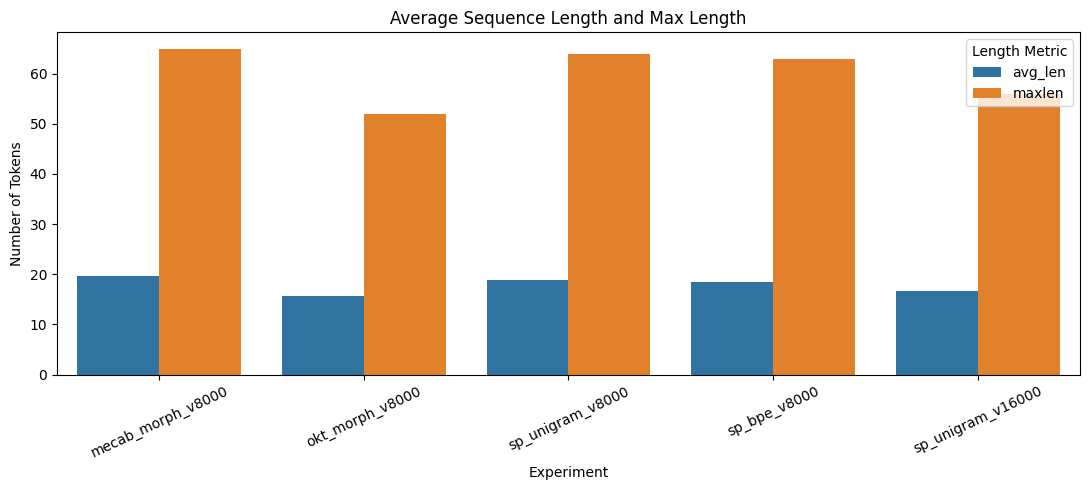

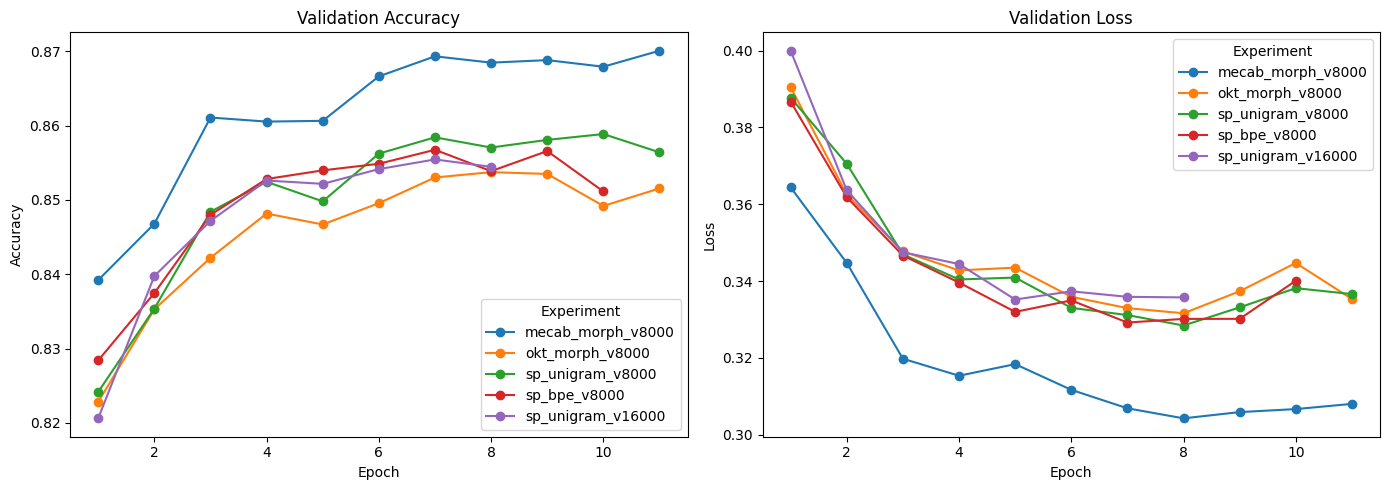

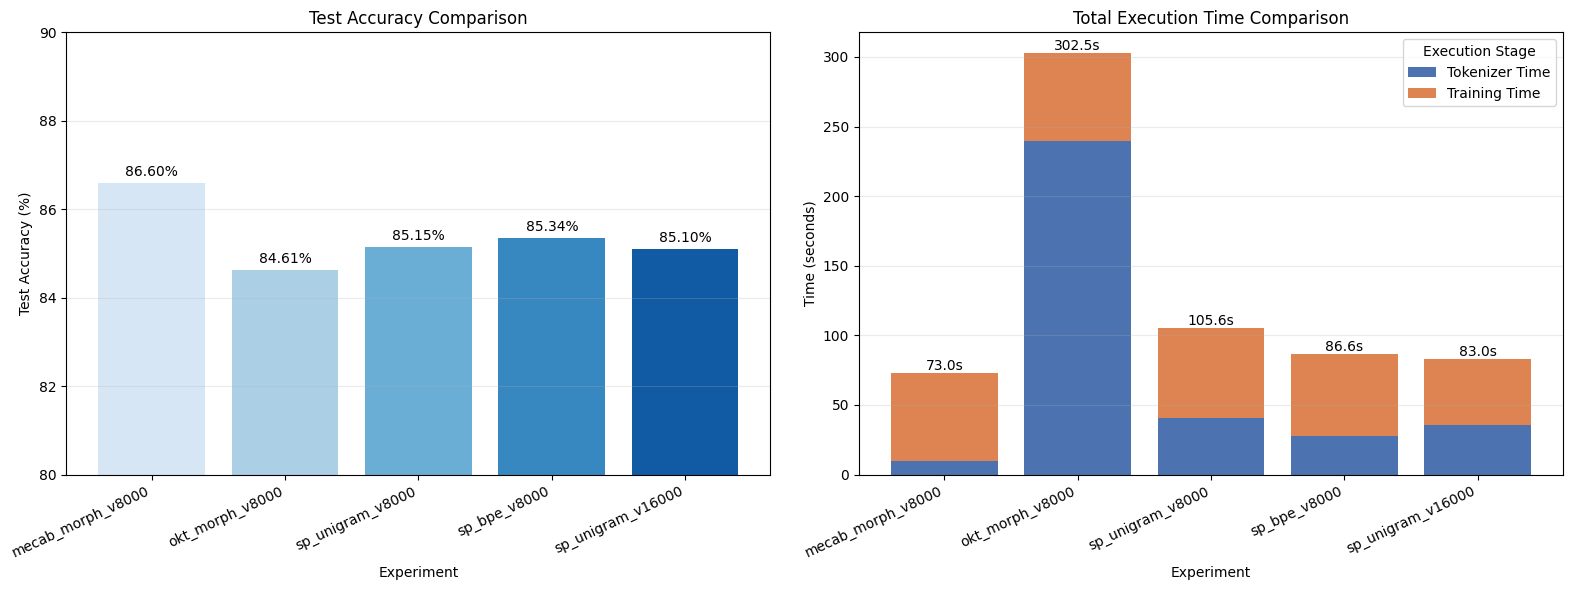

In [16]:
def plot_sequence_lengths(results_df):
    if results_df.empty:
        print("No completed results are available for plotting.")
        return

    plot_df = results_df.copy()
    order = plot_df["experiment_name"].tolist()
    length_plot = plot_df.melt(
        id_vars="experiment_name",
        value_vars=["avg_len", "maxlen"],
        var_name="length_metric",
        value_name="tokens",
    )

    plt.figure(figsize=(11, 5))
    ax = sns.barplot(
        data=length_plot,
        x="experiment_name",
        y="tokens",
        hue="length_metric",
        order=order,
    )
    ax.set_title("Average Sequence Length and Max Length")
    ax.set_xlabel("Experiment")
    ax.set_ylabel("Number of Tokens")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="Length Metric")
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / "sequence_length_by_tokenizer.png",
        dpi=150,
    )
    plt.show()


def plot_validation_histories(results_df):
    if results_df.empty:
        print("No completed histories are available for plotting.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plotted = False

    for experiment_name in results_df["experiment_name"]:
        history_path = HISTORY_DIR / f"history_{experiment_name}.csv"
        if not history_path.exists():
            continue

        history = pd.read_csv(history_path)
        axes[0].plot(
            history["epoch"],
            history["val_acc"],
            marker="o",
            label=experiment_name,
        )
        axes[1].plot(
            history["epoch"],
            history["val_loss"],
            marker="o",
            label=experiment_name,
        )
        plotted = True

    if not plotted:
        plt.close(fig)
        print("No saved history CSV files were found.")
        return

    axes[0].set_title("Validation Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(title="Experiment")

    axes[1].set_title("Validation Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend(title="Experiment")

    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / "validation_history_comparison.png",
        dpi=150,
    )
    plt.show()


def plot_overall_performance(results_df):
    if results_df.empty:
        print("No completed results are available for plotting.")
        return

    required_columns = [
        "experiment_name",
        "test_acc",
        "tokenize_time_sec",
        "train_time_sec",
    ]
    missing_columns = [
        column for column in required_columns
        if column not in results_df.columns
    ]
    if missing_columns:
        raise KeyError(f"Missing result columns: {missing_columns}")

    plot_df = results_df[required_columns].copy()
    if plot_df.isna().any().any():
        raise ValueError("Overall performance results contain missing values.")

    plot_df["test_acc_percent"] = plot_df["test_acc"] * 100
    plot_df["total_time_sec"] = (
        plot_df["tokenize_time_sec"]
        + plot_df["train_time_sec"]
    )
    assert np.allclose(
        plot_df["total_time_sec"],
        plot_df["tokenize_time_sec"] + plot_df["train_time_sec"],
    )

    experiment_names = plot_df["experiment_name"].tolist()
    positions = np.arange(len(plot_df))
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    accuracy_bars = axes[0].bar(
        positions,
        plot_df["test_acc_percent"],
        color=sns.color_palette("Blues", len(plot_df)),
    )
    axes[0].bar_label(
        accuracy_bars,
        labels=[f"{value:.2f}%" for value in plot_df["test_acc_percent"]],
        padding=3,
    )
    axes[0].set_title("Test Accuracy Comparison")
    axes[0].set_xlabel("Experiment")
    axes[0].set_ylabel("Test Accuracy (%)")
    axes[0].set_ylim(80, 90)
    axes[0].set_xticks(positions, experiment_names, rotation=25, ha="right")
    axes[0].grid(axis="y", alpha=0.25)

    axes[1].bar(
        positions,
        plot_df["tokenize_time_sec"],
        label="Tokenizer Time",
        color="#4C72B0",
    )
    axes[1].bar(
        positions,
        plot_df["train_time_sec"],
        bottom=plot_df["tokenize_time_sec"],
        label="Training Time",
        color="#DD8452",
    )
    for position, total_time in zip(
        positions,
        plot_df["total_time_sec"],
    ):
        axes[1].text(
            position,
            total_time,
            f"{total_time:.1f}s",
            ha="center",
            va="bottom",
        )

    axes[1].set_title("Total Execution Time Comparison")
    axes[1].set_xlabel("Experiment")
    axes[1].set_ylabel("Time (seconds)")
    axes[1].set_xticks(positions, experiment_names, rotation=25, ha="right")
    axes[1].legend(title="Execution Stage")
    axes[1].grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / "overall_performance_comparison.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()


plot_sequence_lengths(tokenizer_results)
plot_validation_histories(tokenizer_results)
plot_overall_performance(tokenizer_results)

### 결과 및 회고 

 * **한줄 요약 : Mecab 짱짱**   
  
  

> MeCab 8k는 다섯 조건 중 가장 높은 test accuracy와 가장 짧은 총 실행 시간을 함께 기록하였다.  
> Okt 8k는 학습 시간은 다른 조건과 비슷했지만 **형태소 분석 시간이 압도적으로 길어** 총 실행 시간이 가장 길었으며, 정확도 또한 가장 낮고 UNK 비율도 가장 높았다. **(mecab 대비 acc -2%p, UNK +250%), 총 실행시간 약 4배**  

> 단, `train_time_sec`는 validation loss을 기반으로 3 epoch동안 개선이 없을 경우 early stopping을 적용하여 수행한 전체 학습 시간이므로 실험마다 실행 epoch 수가 달라 **원래는 1대1 비교가 불가능하지만**, 정확도와 수렴 양상이 대부분 비슷(크게 과대적합되지는 않은 것으로 보임)한 점을 참고하면 그냥 빠를수록 좋았다고 해석할 수도 있을 것 같다. 

> sentence piece 계열의 경우 그냥저냥 괜찮은 정확도와 실행 시간을 보였다.  
 sp unigram의 경우 vocab=8000, 16000 양측에서 정확도는 거의 비슷했으나 후자의 경우 실행 속도가 개선되는 양상을 보였고 bpe v=8000의 경우 조금 더 괜찮은 정확도와 unigram-16000의 실행 시간을 모두 잡은 모습이라 무난하게 쓰기 괜찮을 것 같다.  
 특ㄱ기할 점으로는 sp 계열은 UNK 비율이 매우 낮았다.    



과적합 판단에 참고한 train/val loss, val acc
  

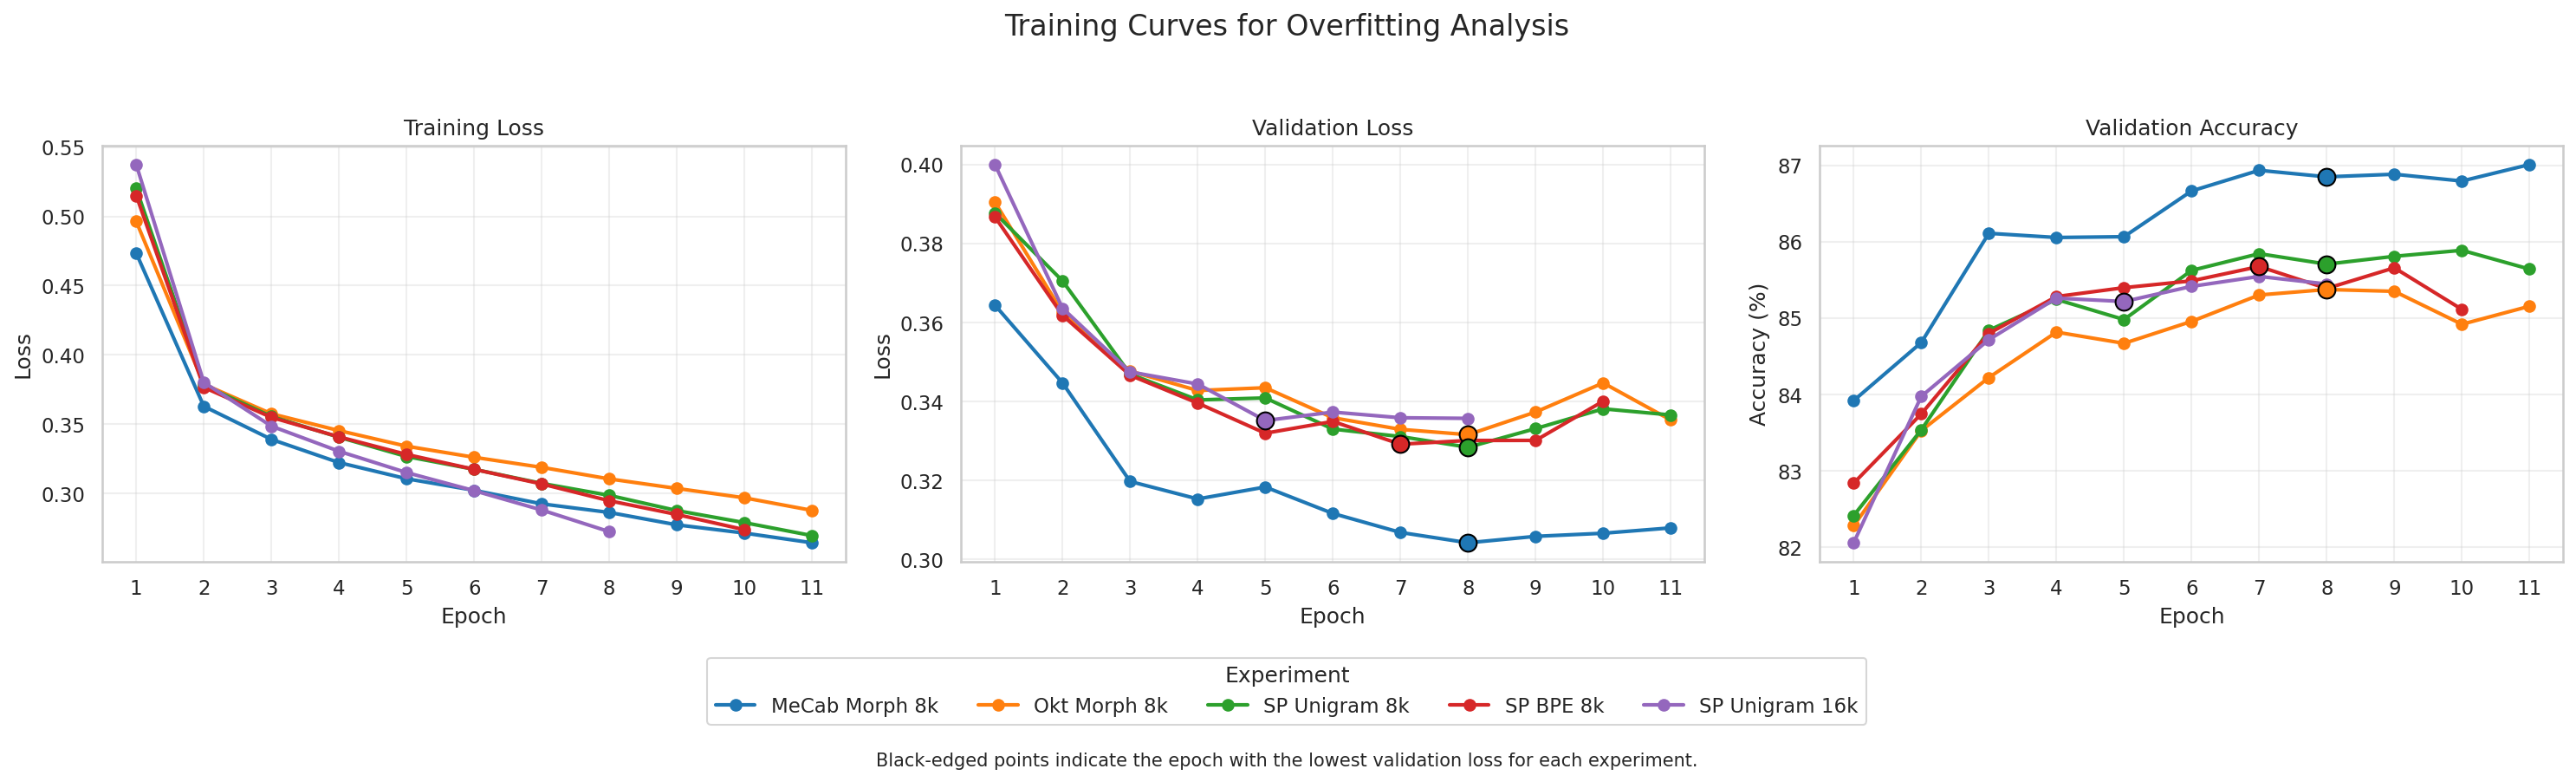